Parámetros de adquisición
  equipment           : Nikon XT H 225
  energy_kV           : 150
  pixel_size_um       : 20
  material            : Mortero de cemento
  phases              : ['Poros', 'Resina', 'Matriz de cemento']


Información de la imagen
  Dimensiones        : 1180 x 1188 píxeles
  Campo de visión    : 23.60 x 23.76 mm
  Tipo de dato       : uint16
  Valor mínimo       : 4930
  Valor máximo       : 59483
  Media              : 24073.0
  Desviación estándar: 10078.8


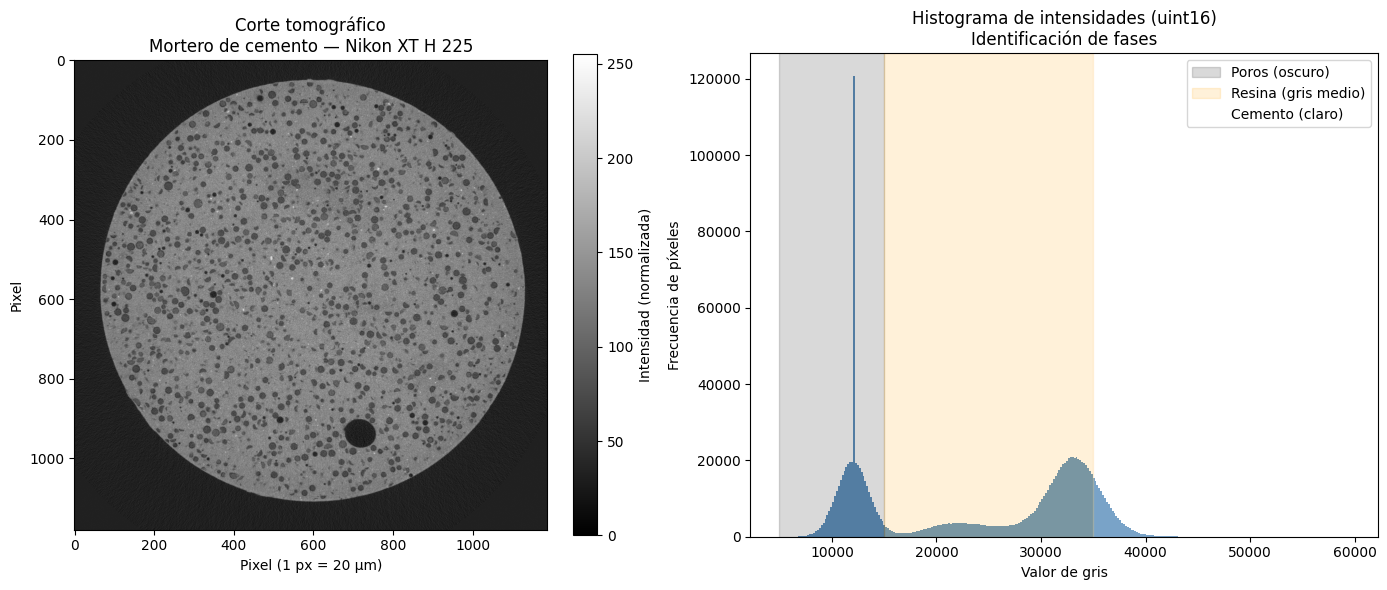


  Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis\figures\01_exploracion_imagen.png


In [27]:
# ============================================================
# PROYECTO 01 - Análisis de Porosidad en Mortero de Cemento
# 1. Exploración y comprensión de los datos
# ============================================================
# Autor: Peter Zabala Medina, PhD
# Equipo: Nikon XT H 225
# ============================================================

import numpy as np
import tifffile
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ------------------------------------------------------------
# 1.1 - Parámetros de adquisición
# ------------------------------------------------------------
# Estos parámetros convierten los resultados de píxeles a 
# unidades físicas reales. Son la base de todo el análisis.

ACQUISITION_PARAMS = {
    "equipment"  : "Nikon XT H 225",
    "energy_kV"  : 150,
    "pixel_size_um": 20,        # micrones por pixel
    "material"   : "Mortero de cemento",
    "phases"     : ["Poros", "Resina", "Matriz de cemento"],
}

print("=" * 50)
print("Parámetros de adquisición")
print("=" * 50)
for key, value in ACQUISITION_PARAMS.items():
    print(f"  {key:20s}: {value}")

# ------------------------------------------------------------
# 1.2 - Rutas del proyecto
# ------------------------------------------------------------

BASE_DIR    = Path(r"C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis")
DATA_RAW    = BASE_DIR / "data" / "raw"
FIGURES_DIR = BASE_DIR / "figures"
RESULTS_DIR = BASE_DIR / "results"

IMAGE_PATH  = DATA_RAW / "Muestra01.tif"

# ------------------------------------------------------------
# 1.3 - Carga de imagen
# Nota: esta función es el punto de entrada del pipeline.
# En el proyecto 3D, se llamará una vez por corte dentro
# de un loop de procesamiento por lotes.
# ------------------------------------------------------------

def load_image(path: Path) -> np.ndarray:
    """
    Carga una imagen TIFF de cortes tomográficos.
    
    Parameters
    ----------
    path : Path
        Ruta al archivo .tif
    
    Returns
    -------
    np.ndarray
        Imagen en formato uint16
    """
    img = tifffile.imread(path)
    return img

img = load_image(IMAGE_PATH)

# ------------------------------------------------------------
# 1.4 - Información básica de la imagen
# ------------------------------------------------------------

pixel_size  = ACQUISITION_PARAMS["pixel_size_um"]
height, width = img.shape
fov_mm = (height * pixel_size / 1000, width * pixel_size / 1000)

print("\n")
print("=" * 50)
print("Información de la imagen")
print("=" * 50)
print(f"  Dimensiones        : {height} x {width} píxeles")
print(f"  Campo de visión    : {fov_mm[0]:.2f} x {fov_mm[1]:.2f} mm")
print(f"  Tipo de dato       : {img.dtype}")
print(f"  Valor mínimo       : {img.min()}")
print(f"  Valor máximo       : {img.max()}")
print(f"  Media              : {img.mean():.1f}")
print(f"  Desviación estándar: {img.std():.1f}")

# ------------------------------------------------------------
# 1.5 - Visualización exploratoria
# ------------------------------------------------------------

def plot_exploration(img: np.ndarray, params: dict, save_path: Path) -> None:
    """
    Genera figura exploratoria con imagen e histograma de intensidades.
    Identifica visualmente las fases presentes en la muestra.

    Parameters
    ----------
    img     : np.ndarray  Imagen tomográfica uint16
    params  : dict        Parámetros de adquisición
    save_path : Path      Ruta donde guardar la figura
    """
    # Normalizar a uint8 solo para visualización
    img_vis = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)

    fig = plt.figure(figsize=(14, 6))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2])

    # --- Imagen ---
    ax0 = fig.add_subplot(gs[0])
    im  = ax0.imshow(img_vis, cmap="gray")
    ax0.set_title(f"Corte tomográfico\n{params['material']} — {params['equipment']}", fontsize=12)
    ax0.set_xlabel(f"Pixel (1 px = {params['pixel_size_um']} µm)")
    ax0.set_ylabel("Pixel")
    plt.colorbar(im, ax=ax0, fraction=0.046, label="Intensidad (normalizada)")

    # --- Histograma ---
    ax1 = fig.add_subplot(gs[1])
    ax1.hist(img.ravel(), bins=300, color="steelblue", alpha=0.85, linewidth=0.3)
    ax1.set_title("Histograma de intensidades (uint16)\nIdentificación de fases", fontsize=12)
    ax1.set_xlabel("Valor de gris")
    ax1.set_ylabel("Frecuencia de píxeles")

    # Anotaciones de fases (aproximadas — se ajustan en 3)
    ax1.axvspan(img.min(), 15000, alpha=0.15, color="black",  label="Poros (oscuro)")
    ax1.axvspan(15000,     35000, alpha=0.15, color="orange", label="Resina (gris medio)")
    ax1.axvspan(35000, img.max(), alpha=0.15, color="white",  label="Cemento (claro)")
    ax1.legend(fontsize=10)

    plt.tight_layout()
    out = save_path / "01_exploracion_imagen.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n  Figura guardada en: {out}")

plot_exploration(img, ACQUISITION_PARAMS, FIGURES_DIR)

Normalización
  Tipo original    : uint16  rango [4930, 59483]
  Tipo normalizado : float32  rango [0.000, 1.000]

  SNR estimado     : 1.90
  Evaluación       : Ruido significativo — filtrado recomendado


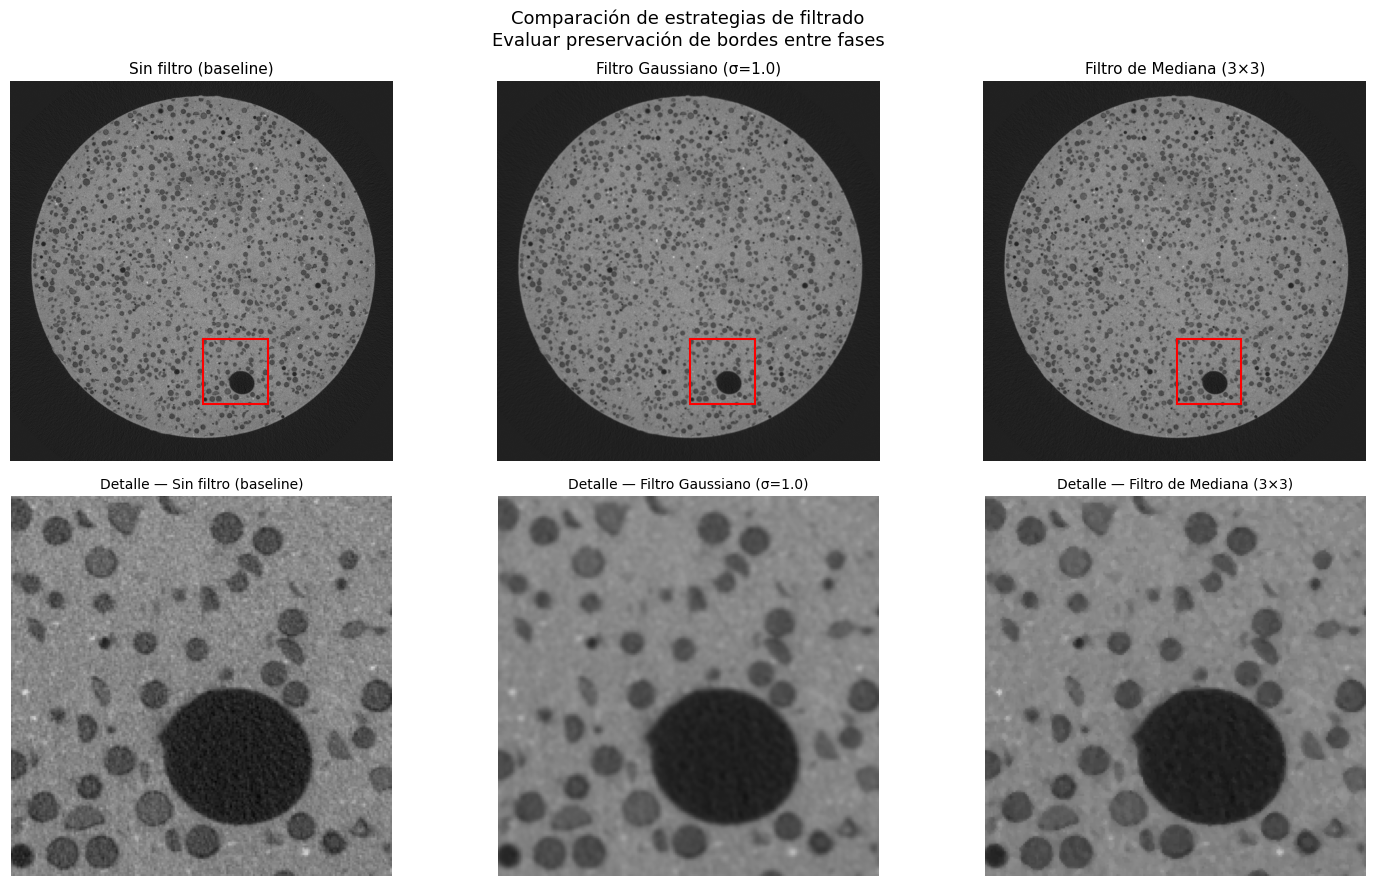

  Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis\figures\02_comparacion_filtros.png


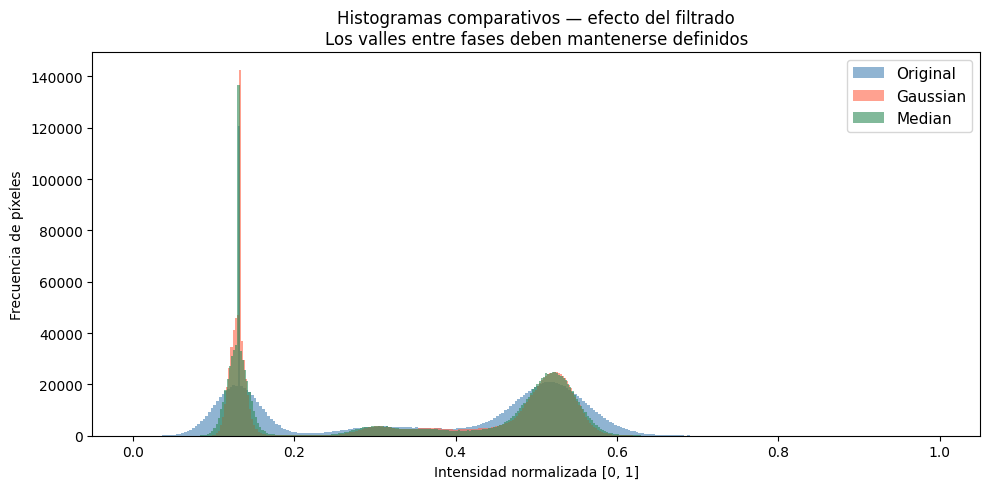

  Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis\figures\02_histogramas_filtrado.png


Imagen preprocesada lista para segmentación
  Filtro seleccionado : median
  Shape               : (1180, 1188)
  Dtype               : float32
  Rango               : [0.065, 0.876]


In [2]:
# ============================================================
# 2. - Preprocesamiento
# ============================================================
# Objetivo: preparar la imagen para la segmentación.
# Decisiones tomadas acá afectan directamente la calidad
# de las máscaras en 3.
# ============================================================

from scipy.ndimage import gaussian_filter, median_filter
from skimage.exposure import rescale_intensity

# ------------------------------------------------------------
# 2.1 - Normalización de intensidades
# Convertimos uint16 a float32 en rango [0, 1].
# Trabajar en float evita errores de overflow en operaciones
# posteriores y es la práctica estándar en CV científica.
# ------------------------------------------------------------

def normalize_image(img: np.ndarray) -> np.ndarray:
    """
    Normaliza una imagen uint16 a float32 en rango [0, 1].
    
    Parameters
    ----------
    img : np.ndarray
        Imagen original uint16
    
    Returns
    -------
    np.ndarray
        Imagen normalizada float32 en [0, 1]
    """
    img_float = img.astype(np.float32)
    img_norm  = (img_float - img_float.min()) / (img_float.max() - img_float.min())
    return img_norm

img_norm = normalize_image(img)

print("=" * 50)
print("Normalización")
print("=" * 50)
print(f"  Tipo original    : {img.dtype}  rango [{img.min()}, {img.max()}]")
print(f"  Tipo normalizado : {img_norm.dtype}  rango [{img_norm.min():.3f}, {img_norm.max():.3f}]")

# ------------------------------------------------------------
# 2.2 - Evaluación de ruido
# Antes de filtrar, evaluamos si la imagen lo necesita.
# En imágenes de microCT de buena calidad muchas veces
# el filtrado no mejora — y puede borrar bordes reales.
# Calculamos el SNR como métrica objetiva.
# ------------------------------------------------------------

def estimate_snr(img: np.ndarray) -> float:
    """
    Estima el Signal-to-Noise Ratio como mean/std.
    Un SNR > 10 generalmente indica imagen de buena calidad.

    Parameters
    ----------
    img : np.ndarray
        Imagen normalizada float32

    Returns
    -------
    float
        Valor de SNR estimado
    """
    snr = img.mean() / img.std()
    return snr

snr = estimate_snr(img_norm)
print(f"\n  SNR estimado     : {snr:.2f}")
print(f"  Evaluación       : {'Buena calidad — filtrado opcional' if snr > 5 else 'Ruido significativo — filtrado recomendado'}")

# ------------------------------------------------------------
# 2.3 - Comparación de filtros
# Evaluamos tres opciones:
#   - Sin filtro (baseline)
#   - Filtro gaussiano (suavizado general)
#   - Filtro de mediana (preserva bordes mejor)
# La decisión final se toma visualmente y con el histograma.
# ------------------------------------------------------------

def apply_filters(img: np.ndarray, gaussian_sigma: float = 1.0,
                  median_size: int = 3) -> dict:
    """
    Aplica filtros de suavizado y retorna todas las versiones
    para comparación visual.

    Parameters
    ----------
    img            : np.ndarray  Imagen normalizada float32
    gaussian_sigma : float       Sigma para filtro gaussiano
    median_size    : int         Tamaño de ventana para mediana

    Returns
    -------
    dict con versiones: original, gaussian, median
    """
    return {
        "original" : img,
        "gaussian" : gaussian_filter(img, sigma=gaussian_sigma).astype(np.float32),
        "median"   : median_filter(img,  size=median_size).astype(np.float32),
    }

filtered_versions = apply_filters(img_norm, gaussian_sigma=1.0, median_size=3)

# ------------------------------------------------------------
# 2.4 - Visualización comparativa de filtros
# ------------------------------------------------------------

def plot_filter_comparison(versions: dict, save_path: Path) -> None:
    """
    Figura comparativa de las tres versiones de filtrado.
    Incluye imagen y detalle ampliado para evaluar bordes,
    más histograma superpuesto para comparar distribuciones.

    Parameters
    ----------
    versions  : dict   Diccionario con versiones filtradas
    save_path : Path   Ruta donde guardar la figura
    """
    titles = {
        "original" : "Sin filtro (baseline)",
        "gaussian" : "Filtro Gaussiano (σ=1.0)",
        "median"   : "Filtro de Mediana (3×3)",
    }

    # Región de detalle para comparar bordes
    row_s, row_e = 800, 1000
    col_s, col_e = 600, 800

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))

    for col, (key, img_v) in enumerate(versions.items()):

        # Fila superior — imagen completa
        axes[0, col].imshow(img_v, cmap="gray", vmin=0, vmax=1)
        axes[0, col].set_title(titles[key], fontsize=11)
        axes[0, col].add_patch(plt.Rectangle(
            (col_s, row_s), col_e - col_s, row_e - row_s,
            edgecolor="red", facecolor="none", linewidth=1.5))
        axes[0, col].axis("off")

        # Fila inferior — detalle ampliado
        axes[1, col].imshow(img_v[row_s:row_e, col_s:col_e],
                            cmap="gray", vmin=0, vmax=1)
        axes[1, col].set_title(f"Detalle — {titles[key]}", fontsize=10)
        axes[1, col].axis("off")

    plt.suptitle("Comparación de estrategias de filtrado\n"
                 "Evaluar preservación de bordes entre fases", fontsize=13)
    plt.tight_layout()
    out = save_path / "02_comparacion_filtros.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Figura guardada en: {out}")


def plot_histogram_comparison(versions: dict, save_path: Path) -> None:
    """
    Histogramas superpuestos de las tres versiones.
    Permite evaluar si el filtrado borra separación entre fases.

    Parameters
    ----------
    versions  : dict   Diccionario con versiones filtradas
    save_path : Path   Ruta donde guardar la figura
    """
    colors = {"original": "steelblue", "gaussian": "tomato", "median": "seagreen"}

    fig, ax = plt.subplots(figsize=(10, 5))
    for key, img_v in versions.items():
        ax.hist(img_v.ravel(), bins=300, alpha=0.6,
                color=colors[key], label=key.capitalize(), linewidth=0.3)

    ax.set_title("Histogramas comparativos — efecto del filtrado\n"
                 "Los valles entre fases deben mantenerse definidos", fontsize=12)
    ax.set_xlabel("Intensidad normalizada [0, 1]")
    ax.set_ylabel("Frecuencia de píxeles")
    ax.legend(fontsize=11)

    plt.tight_layout()
    out = save_path / "02_histogramas_filtrado.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Figura guardada en: {out}")


plot_filter_comparison(filtered_versions, FIGURES_DIR)
plot_histogram_comparison(filtered_versions, FIGURES_DIR)

# ------------------------------------------------------------
# 2.5 - Selección de imagen preprocesada
# Después de evaluar las figuras anteriores, elegís cuál
# versión usar en el Acto 3. Por defecto usamos mediana
# porque preserva mejor los bordes entre fases.
# Cambiá la key si tu evaluación visual indica otra cosa.
# ------------------------------------------------------------

FILTER_SELECTED = "median"   # opciones: "original", "gaussian", "median"

img_preprocessed = filtered_versions[FILTER_SELECTED]

print("\n")
print("=" * 50)
print("Imagen preprocesada lista para segmentación")
print("=" * 50)
print(f"  Filtro seleccionado : {FILTER_SELECTED}")
print(f"  Shape               : {img_preprocessed.shape}")
print(f"  Dtype               : {img_preprocessed.dtype}")
print(f"  Rango               : [{img_preprocessed.min():.3f}, {img_preprocessed.max():.3f}]")

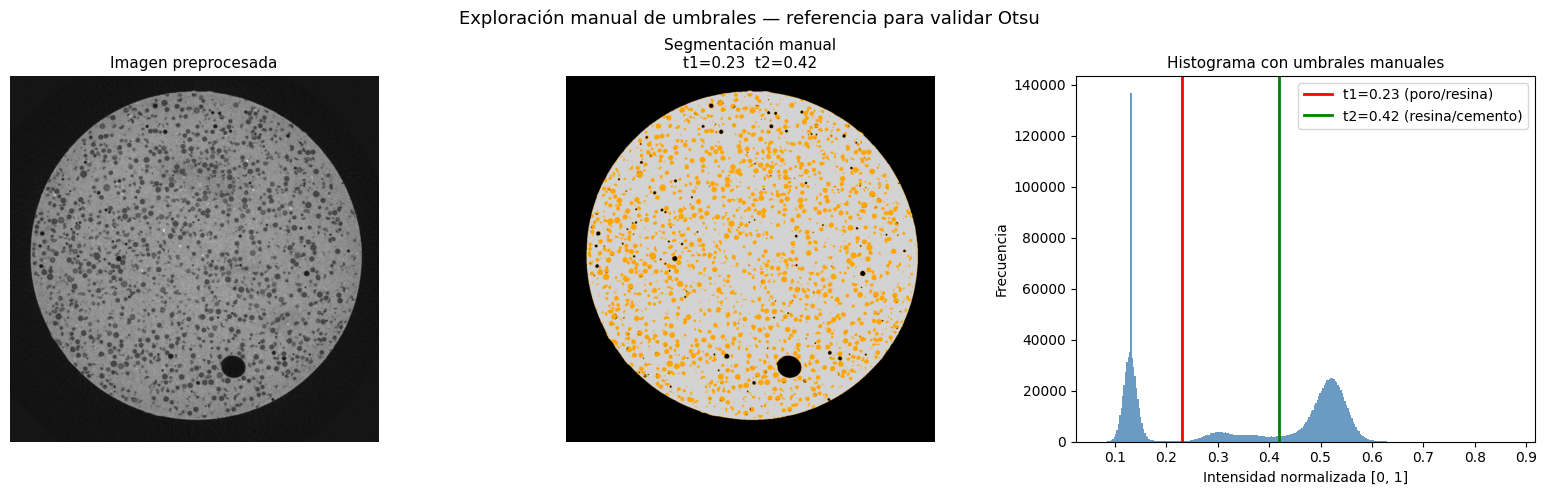

  Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis\figures\03_umbrales_manuales.png
Umbrales Otsu multi-nivel
  Umbral poros/resina    : 0.2313
  Umbral resina/cemento  : 0.4246

  Referencia manual      : t1=0.23  t2=0.42
  Coincidencia           : ✓ Buena / ✓ Buena


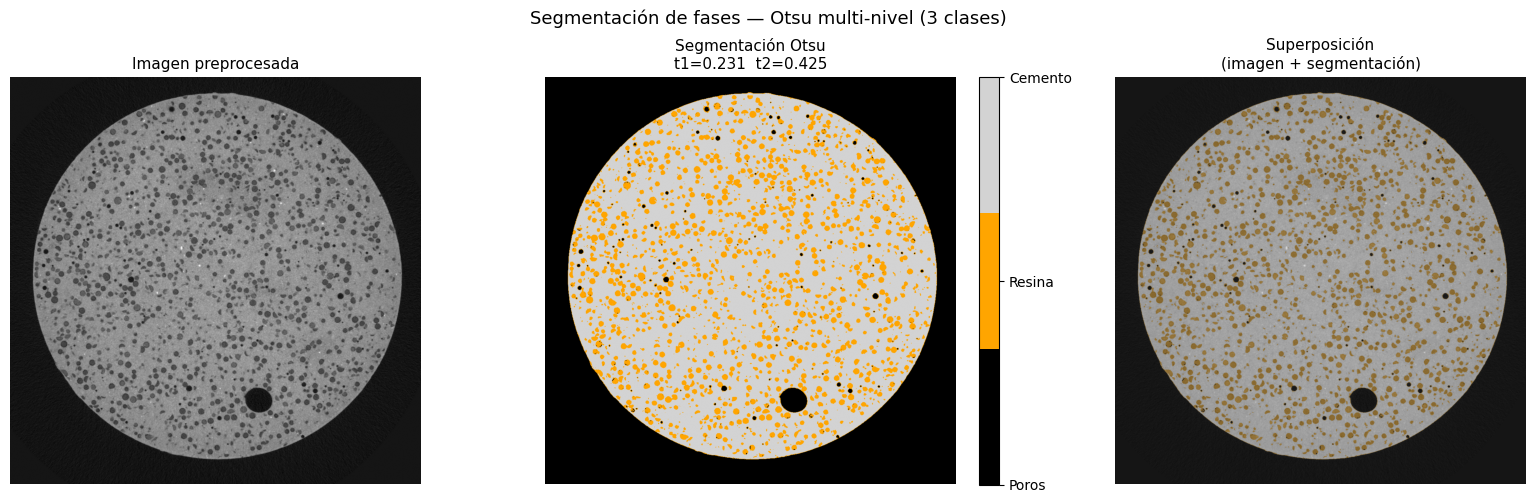

  Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis\figures\03_segmentacion_fases.png


Fracción de área por fase (antes de limpieza)
  Poros     :  37.3%  ██████████████████
  Resina    :  11.8%  █████
  Cemento   :  50.9%  █████████████████████████

  ⚠ Valores preliminares — la limpieza morfológica
    en 4 puede modificar estos porcentajes.


In [3]:
# ============================================================
# 3. - Segmentación de fases
# ============================================================
# Objetivo: separar las tres fases de la imagen en una
# máscara etiquetada:
#   0 = Poros
#   1 = Resina
#   2 = Matriz de cemento
#
# Estrategia: umbralización multi-nivel con Otsu.
# Primero exploramos manualmente los umbrales para entender
# el problema, luego automatizamos con Otsu.
# ============================================================

from skimage.filters import threshold_otsu, threshold_multiotsu
from skimage.color import label2rgb
import matplotlib.colors as mcolors

# ------------------------------------------------------------
# 3.1 - Umbralización manual exploratoria
# Antes de automatizar, exploramos el histograma para
# entender dónde están los valles entre fases.
# Esto desarrolla intuición sobre los datos y permite
# validar que Otsu encuentra los umbrales correctos.
# Los valores de t1 y t2 son aproximados — ajustalos
# después de mirar el histograma del Acto 1.
# ------------------------------------------------------------

def explore_manual_thresholds(img: np.ndarray, t1: float, t2: float,
                               save_path: Path) -> None:
    """
    Visualiza el efecto de dos umbrales manuales sobre la imagen
    y los marca en el histograma.

    Parameters
    ----------
    img       : np.ndarray  Imagen preprocesada float32 [0,1]
    t1        : float       Umbral entre poros y resina
    t2        : float       Umbral entre resina y cemento
    save_path : Path        Ruta donde guardar la figura
    """
    mask_manual = np.zeros_like(img, dtype=np.uint8)
    mask_manual[img >= t1] = 1   # resina
    mask_manual[img >= t2] = 2   # cemento
    # píxeles por debajo de t1 quedan en 0 = poros

    phase_colors = {0: "black", 1: "orange", 2: "lightgray"}
    cmap_manual  = mcolors.ListedColormap([phase_colors[i] for i in range(3)])

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Imagen preprocesada
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Imagen preprocesada", fontsize=11)
    axes[0].axis("off")

    # Máscara manual
    axes[1].imshow(mask_manual, cmap=cmap_manual, vmin=0, vmax=2)
    axes[1].set_title(f"Segmentación manual\nt1={t1:.2f}  t2={t2:.2f}", fontsize=11)
    axes[1].axis("off")

    # Histograma con umbrales marcados
    axes[2].hist(img.ravel(), bins=300, color="steelblue",
                 alpha=0.8, linewidth=0.3)
    axes[2].axvline(t1, color="red",    linewidth=2, label=f"t1={t1:.2f} (poro/resina)")
    axes[2].axvline(t2, color="green",  linewidth=2, label=f"t2={t2:.2f} (resina/cemento)")
    axes[2].set_title("Histograma con umbrales manuales", fontsize=11)
    axes[2].set_xlabel("Intensidad normalizada [0, 1]")
    axes[2].set_ylabel("Frecuencia")
    axes[2].legend(fontsize=10)

    plt.suptitle("Exploración manual de umbrales — referencia para validar Otsu",
                 fontsize=13)
    plt.tight_layout()
    out = save_path / "03_umbrales_manuales.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Figura guardada en: {out}")


# --- Ajustá estos valores mirando el histograma del Acto 1 ---
T1_MANUAL = 0.23   # umbral aproximado poros / resina
T2_MANUAL = 0.42   # umbral aproximado resina / cemento

explore_manual_thresholds(img_preprocessed, T1_MANUAL, T2_MANUAL, FIGURES_DIR)

# ------------------------------------------------------------
# 3.2 - Umbralización automática con Otsu multi-nivel
# Otsu encuentra los umbrales que maximizan la varianza
# entre clases. Para 3 fases necesitamos 2 umbrales,
# por eso usamos threshold_multiotsu con nclasses=3.
# ------------------------------------------------------------

def compute_otsu_thresholds(img: np.ndarray, nclasses: int = 3) -> np.ndarray:
    """
    Calcula umbrales automáticos con Otsu multi-nivel.

    Parameters
    ----------
    img      : np.ndarray  Imagen preprocesada float32 [0,1]
    nclasses : int         Número de fases a separar (default: 3)

    Returns
    -------
    np.ndarray
        Array con los umbrales encontrados
    """
    thresholds = threshold_multiotsu(img, classes=nclasses)
    return thresholds

otsu_thresholds = compute_otsu_thresholds(img_preprocessed, nclasses=3)

print("=" * 50)
print("Umbrales Otsu multi-nivel")
print("=" * 50)
print(f"  Umbral poros/resina    : {otsu_thresholds[0]:.4f}")
print(f"  Umbral resina/cemento  : {otsu_thresholds[1]:.4f}")
print(f"\n  Referencia manual      : t1={T1_MANUAL:.2f}  t2={T2_MANUAL:.2f}")
print(f"  Coincidencia           : {'✓ Buena' if abs(otsu_thresholds[0]-T1_MANUAL) < 0.05 else '⚠ Revisar t1'} / "
      f"{'✓ Buena' if abs(otsu_thresholds[1]-T2_MANUAL) < 0.05 else '⚠ Revisar t2'}")

# ------------------------------------------------------------
# 3.3 - Generación de máscara de segmentación
# ------------------------------------------------------------

def segment_phases(img: np.ndarray, thresholds: np.ndarray) -> np.ndarray:
    """
    Genera máscara etiquetada con las tres fases usando
    los umbrales provistos.

    Etiquetas:
        0 = Poros       (intensidad baja)
        1 = Resina      (intensidad media)
        2 = Cemento     (intensidad alta)

    Parameters
    ----------
    img        : np.ndarray  Imagen preprocesada float32 [0,1]
    thresholds : np.ndarray  Dos umbrales de separación de fases

    Returns
    -------
    np.ndarray
        Máscara uint8 con etiquetas 0, 1, 2
    """
    mask = np.zeros_like(img, dtype=np.uint8)
    mask[img >= thresholds[0]] = 1   # resina
    mask[img >= thresholds[1]] = 2   # cemento
    return mask

mask_segmented = segment_phases(img_preprocessed, otsu_thresholds)

# ------------------------------------------------------------
# 3.4 - Visualización de la segmentación Otsu
# ------------------------------------------------------------

def plot_segmentation(img: np.ndarray, mask: np.ndarray,
                      thresholds: np.ndarray, save_path: Path) -> None:
    """
    Figura final de segmentación: imagen original, máscara
    de fases y superposición con transparencia.

    Parameters
    ----------
    img        : np.ndarray  Imagen preprocesada
    mask       : np.ndarray  Máscara segmentada (0,1,2)
    thresholds : np.ndarray  Umbrales Otsu usados
    save_path  : Path        Ruta donde guardar la figura
    """
    phase_colors = ["black", "orange", "lightgray"]
    phase_labels = ["Poros", "Resina", "Cemento"]
    cmap_seg     = mcolors.ListedColormap(phase_colors)

    # Superposición con transparencia
    overlay = label2rgb(mask, image=img, colors=phase_colors[1:],
                        bg_label=0, bg_color=(0, 0, 0), alpha=0.35)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Imagen preprocesada", fontsize=11)
    axes[0].axis("off")

    im = axes[1].imshow(mask, cmap=cmap_seg, vmin=0, vmax=2)
    axes[1].set_title(f"Segmentación Otsu\nt1={thresholds[0]:.3f}  "
                      f"t2={thresholds[1]:.3f}", fontsize=11)
    axes[1].axis("off")
    cbar = plt.colorbar(im, ax=axes[1], ticks=[0, 1, 2], fraction=0.046)
    cbar.ax.set_yticklabels(phase_labels)

    axes[2].imshow(overlay)
    axes[2].set_title("Superposición\n(imagen + segmentación)", fontsize=11)
    axes[2].axis("off")

    plt.suptitle("Segmentación de fases — Otsu multi-nivel (3 clases)", fontsize=13)
    plt.tight_layout()
    out = save_path / "03_segmentacion_fases.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Figura guardada en: {out}")


plot_segmentation(img_preprocessed, mask_segmented, otsu_thresholds, FIGURES_DIR)

# ------------------------------------------------------------
# 3.5 - Fracción de área por fase (resultado preliminar)
# Resultado cuantitativo antes de la limpieza morfológica.
# Comparar con los valores del 4 para evaluar el
# impacto de la limpieza sobre las métricas finales.
# ------------------------------------------------------------

def compute_phase_fractions(mask: np.ndarray,
                             phase_names: list) -> dict:
    """
    Calcula la fracción de área de cada fase sobre el
    total de píxeles de la imagen.

    Parameters
    ----------
    mask        : np.ndarray  Máscara segmentada (0,1,2)
    phase_names : list        Nombres de las fases

    Returns
    -------
    dict con fracción de área por fase en porcentaje
    """
    total = mask.size
    fractions = {}
    for label, name in enumerate(phase_names):
        count = np.sum(mask == label)
        fractions[name] = (count / total) * 100
    return fractions

PHASE_NAMES = ["Poros", "Resina", "Cemento"]
fractions   = compute_phase_fractions(mask_segmented, PHASE_NAMES)

print("\n")
print("=" * 50)
print("Fracción de área por fase (antes de limpieza)")
print("=" * 50)
for phase, pct in fractions.items():
    bar = "█" * int(pct / 2)
    print(f"  {phase:10s}: {pct:5.1f}%  {bar}")
print("\n  ⚠ Valores preliminares — la limpieza morfológica")
print("    en 4 puede modificar estos porcentajes.")

C:\Users\Peter\AppData\Local\Temp\ipykernel_7120\2965744815.py:61: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  filled = remove_small_objects(filled, min_size=10000)


ROI circular detectada
  Centroide      : (593.5, 578.5) px
  Radio          : 533.2 px
  Diámetro real  : 21.33 mm
  Área ROI       : 893,108 píxeles


C:\Users\Peter\AppData\Local\Temp\ipykernel_7120\2965744815.py:178: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  pore_binary = binary_opening(pore_binary, footprint=disk(opening_radius))
C:\Users\Peter\AppData\Local\Temp\ipykernel_7120\2965744815.py:181: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  pore_binary = binary_closing(pore_binary, footprint=disk(closing_radius))
C:\Users\Peter\AppData\Local\Temp\ipykernel_7120\2965744815.py:184: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parame

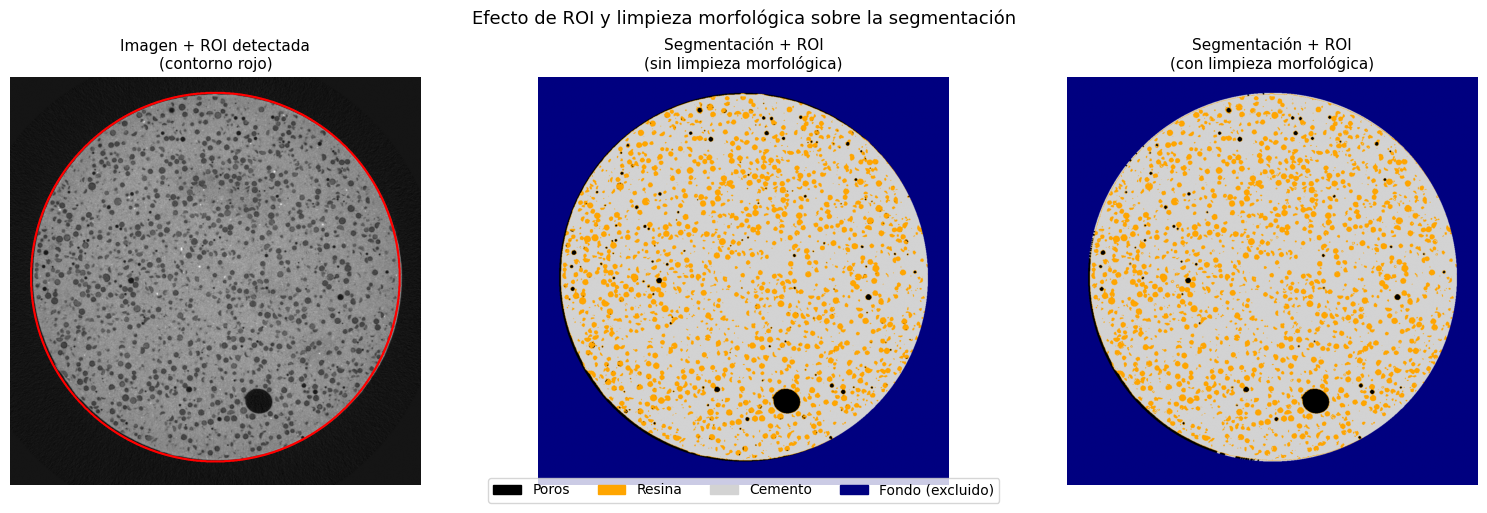

  Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis\figures\04_roi_y_limpieza.png


Análisis de regiones de poros
  Total de poros detectados : 69
  Diámetro mínimo           : 81.4 µm
  Diámetro máximo           : 1503.9 µm
  Diámetro promedio         : 188.4 µm
  Diámetro mediano          : 137.3 µm
  Circularidad promedio     : 0.950

  Primeras 5 filas del DataFrame:
 label  eccentricity  area_um2  diameter_um  perimeter_um  centroid_x_um  centroid_y_um  circularity
     1      0.397360    7200.0    95.746147    266.274170   11350.000000     960.000000     1.000000
     2      0.397360    7200.0    95.746147    266.274170   10470.000000    1040.000000     1.000000
     3      0.394628   56000.0   267.023247    840.832611    9340.857143    1913.285714     0.995357
     4      0.257977   22400.0   168.880330    499.411255   15178.571429    2319.642857     1.000000
     5      0.380893   26000.0   181.945674    539.411255   13034.153846    23

In [8]:
# ============================================================
# 4. - Limpieza morfológica y análisis de regiones
# ============================================================
# Objetivo: 
#   1. Separar el fondo exterior (aire) de los poros reales
#      mediante una máscara ROI circular de la muestra.
#   2. Limpiar ruido morfológico dentro de la ROI.
#   3. Analizar cada poro individualmente como región.
#
# Esta separación es crítica: sin ROI la porosidad calculada
# incluye el fondo negro exterior y da valores imposibles.
# ============================================================

from skimage.morphology import (binary_opening, binary_closing,
                                 disk, remove_small_objects)
from skimage.measure    import label, regionprops, regionprops_table
from skimage.draw       import disk as draw_disk
from scipy.ndimage      import binary_fill_holes
import pandas as pd

# ------------------------------------------------------------
# 4.1 - Detección automática de la ROI circular
# La muestra es un cilindro cortado horizontalmente,
# por eso en 2D aparece como un círculo.
# Estrategia: umbral simple sobre la imagen para separar
# muestra de fondo, luego ajustar círculo mínimo.
# ------------------------------------------------------------

def create_circular_roi(img: np.ndarray,
                        threshold: float = 0.12) -> np.ndarray:
    """
    Detecta automáticamente la región circular de la muestra
    y genera una máscara binaria ROI.

    Estrategia:
        1. Umbral bajo para separar muestra de fondo negro
        2. Rellenar huecos internos
        3. Calcular centroide y radio del círculo equivalente
        4. Dibujar círculo perfecto como ROI final

    Parameters
    ----------
    img       : np.ndarray  Imagen normalizada float32 [0,1]
    threshold : float       Umbral para detectar la muestra
                            (default 0.08 — ajustar si ROI
                            no cubre bien la muestra)

    Returns
    -------
    np.ndarray
        Máscara booleana True dentro de la muestra
    """
    # Paso 1 — separar muestra de fondo
    binary = img > threshold

    # Paso 2 — rellenar huecos (poros internos no deben
    # interrumpir la detección del contorno)
    filled = binary_fill_holes(binary)

    # Paso 3 — limpiar objetos pequeños fuera de la muestra
    filled = remove_small_objects(filled, min_size=10000)

    # Paso 4 — calcular propiedades del objeto principal
    labeled  = label(filled)
    props    = regionprops(labeled)
    
    # Tomar el objeto más grande (la muestra)
    main_region = max(props, key=lambda r: r.area)
    
    # Centroide corregido manualmente si está descentrado
    # Ajustar CY_OFFSET para mover el centro verticalmente
    # Valores positivos mueven hacia abajo, negativos hacia arriba
    CY_OFFSET = -11   # píxeles — ajustar hasta que el círculo quede centrado
    cy = main_region.centroid[0] + CY_OFFSET
    cx = main_region.centroid[1]
    
    radius = (main_region.axis_major_length +
              main_region.axis_minor_length) / 4 * 0.78

    # Paso 5 — dibujar círculo perfecto como ROI final
    roi_mask         = np.zeros(img.shape, dtype=bool)
    rr, cc           = draw_disk((cy, cx), radius, shape=img.shape)
    roi_mask[rr, cc] = True

    print("=" * 50)
    print("ROI circular detectada")
    print("=" * 50)
    print(f"  Centroide      : ({cx:.1f}, {cy:.1f}) px")
    print(f"  Radio          : {radius:.1f} px")
    print(f"  Diámetro real  : {radius * 2 * ACQUISITION_PARAMS['pixel_size_um'] / 1000:.2f} mm")
    print(f"  Área ROI       : {roi_mask.sum():,} píxeles")

    return roi_mask


# --- Variable a ajustar si la ROI no queda bien ---
ROI_THRESHOLD = 0.08

roi_mask = create_circular_roi(img_preprocessed, threshold=ROI_THRESHOLD)

# ------------------------------------------------------------
# 4.2 - Aplicar ROI a la máscara segmentada
# Excluimos todo lo que está fuera de la muestra.
# El fondo exterior pasa a una etiqueta separada (3)
# para distinguirlo explícitamente de los poros (0).
# ------------------------------------------------------------

def apply_roi_to_mask(mask: np.ndarray,
                      roi: np.ndarray) -> np.ndarray:
    """
    Aplica la máscara ROI a la segmentación.
    Los píxeles fuera de la ROI reciben etiqueta 3 (fondo).

    Etiquetas resultantes:
        0 = Poros reales (dentro de la muestra)
        1 = Resina
        2 = Cemento
        3 = Fondo exterior (excluido del análisis)

    Parameters
    ----------
    mask : np.ndarray  Máscara segmentada Acto 3 (0,1,2)
    roi  : np.ndarray  Máscara booleana de la ROI

    Returns
    -------
    np.ndarray
        Máscara corregida uint8 con etiquetas 0,1,2,3
    """
    mask_roi          = mask.copy()
    mask_roi[~roi]    = 3    # fondo exterior
    return mask_roi

mask_roi = apply_roi_to_mask(mask_segmented, roi_mask)

# ------------------------------------------------------------
# 4.3 - Limpieza morfológica de los poros
# Dentro de la ROI pueden quedar píxeles aislados mal
# clasificados. Usamos apertura morfológica para eliminar
# ruido pequeño y cierre para unir poros fragmentados.
# ------------------------------------------------------------

def clean_pore_mask(mask_roi: np.ndarray,
                    opening_radius: int = 1,
                    closing_radius: int = 1,
                    min_pore_size:  int = 5) -> np.ndarray:
    """
    Limpia morfológicamente la máscara de poros dentro
    de la ROI.

    Parameters
    ----------
    mask_roi       : np.ndarray  Máscara con ROI aplicada
    opening_radius : int         Radio del elemento estructurante
                                 para apertura (elimina ruido pequeño)
                                 Aumentar si quedan muchos píxeles
                                 aislados. Default: 1
    closing_radius : int         Radio para cierre morfológico
                                 (une poros fragmentados)
                                 Aumentar con cuidado — puede unir
                                 poros que son distintos. Default: 1
    min_pore_size  : int         Área mínima en píxeles para
                                 considerar un poro válido.
                                 Poros menores se eliminan.
                                 Default: 5

    Returns
    -------
    np.ndarray
        Máscara limpia uint8
    """
    mask_clean = mask_roi.copy()

    # Extraer solo los poros dentro de la ROI
    pore_binary = mask_roi == 0

    # Apertura — elimina píxeles aislados pequeños
    pore_binary = binary_opening(pore_binary, footprint=disk(opening_radius))

    # Cierre — suaviza bordes y une fragmentos cercanos
    pore_binary = binary_closing(pore_binary, footprint=disk(closing_radius))

    # Eliminar poros demasiado pequeños
    pore_binary = remove_small_objects(pore_binary, min_size=min_pore_size)

    # Reinsertar poros limpios en la máscara
    mask_clean[mask_roi == 0]  = 2   # reset zona poros a cemento
    mask_clean[pore_binary]    = 0   # reponer poros limpios

    return mask_clean


# --- Variables a ajustar según resultado visual ---
OPENING_RADIUS = 2
CLOSING_RADIUS = 2
MIN_PORE_SIZE  = 2

mask_clean = clean_pore_mask(mask_roi,
                              opening_radius=OPENING_RADIUS,
                              closing_radius=CLOSING_RADIUS,
                              min_pore_size=MIN_PORE_SIZE)

# ------------------------------------------------------------
# 4.4 - Visualización comparativa antes/después de limpieza
# ------------------------------------------------------------

def plot_roi_and_cleaning(img: np.ndarray,
                           mask_roi: np.ndarray,
                           mask_clean: np.ndarray,
                           roi: np.ndarray,
                           save_path: Path) -> None:
    """
    Figura comparativa mostrando el efecto de la ROI
    y la limpieza morfológica.

    Parameters
    ----------
    img        : np.ndarray  Imagen preprocesada
    mask_roi   : np.ndarray  Máscara con ROI sin limpiar
    mask_clean : np.ndarray  Máscara con ROI y limpieza
    roi        : np.ndarray  Máscara booleana ROI
    save_path  : Path        Ruta donde guardar la figura
    """
    import matplotlib.patches as mpatches

    # Colormap con fondo diferenciado
    colors     = ["black", "orange", "lightgray", "navy"]
    labels_txt = ["Poros", "Resina", "Cemento", "Fondo (excluido)"]
    cmap4      = mcolors.ListedColormap(colors)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Imagen con ROI superpuesta
    axes[0].imshow(img, cmap="gray")
    contour_y, contour_x = np.where(
        np.diff(roi.astype(int), axis=0, prepend=0) != 0)
    axes[0].contour(roi, levels=[0.5], colors="red", linewidths=1.5)
    axes[0].set_title("Imagen + ROI detectada\n(contorno rojo)", fontsize=11)
    axes[0].axis("off")

    # Máscara con ROI — sin limpiar
    axes[1].imshow(mask_roi, cmap=cmap4, vmin=0, vmax=3)
    axes[1].set_title("Segmentación + ROI\n(sin limpieza morfológica)", fontsize=11)
    axes[1].axis("off")

    # Máscara limpia
    im = axes[2].imshow(mask_clean, cmap=cmap4, vmin=0, vmax=3)
    axes[2].set_title("Segmentación + ROI\n(con limpieza morfológica)", fontsize=11)
    axes[2].axis("off")

    # Leyenda
    patches = [mpatches.Patch(color=c, label=l)
               for c, l in zip(colors, labels_txt)]
    fig.legend(handles=patches, loc="lower center",
               ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle("Efecto de ROI y limpieza morfológica sobre la segmentación",
                 fontsize=13)
    plt.tight_layout()
    out = save_path / "04_roi_y_limpieza.png"
    plt.savefig(out, dpi=150, bbox_inches="tight", pad_inches=0.3)
    plt.show()
    print(f"  Figura guardada en: {out}")

plot_roi_and_cleaning(img_preprocessed, mask_roi,
                      mask_clean, roi_mask, FIGURES_DIR)

# ------------------------------------------------------------
# 4.5 - Análisis de regiones individuales de poros
# Cada poro es un objeto independiente con propiedades
# geométricas medibles en unidades físicas reales.
# ------------------------------------------------------------

def analyze_phase_regions(mask_clean: np.ndarray,
                           pixel_size_um: float,
                           phase_label: int = 0) -> pd.DataFrame:
    """
    Etiqueta cada región de una fase individualmente y extrae
    propiedades geométricas en unidades físicas.

    Etiquetas disponibles:
        0 = Poros
        1 = Resina
        2 = Cemento

    Properties extraídas por región:
        - area_um2      : área en µm²
        - diameter_um   : diámetro equivalente en µm
        - perimeter_um  : perímetro en µm
        - circularity   : 4π·A/P² clippeado a [0, 1]
        - centroid_x/y  : posición en µm
        - eccentricity  : elongación (0=círculo, 1=línea)

    Parameters
    ----------
    mask_clean    : np.ndarray  Máscara limpia con ROI aplicada
    pixel_size_um : float       Tamaño de pixel en µm
    phase_label   : int         Fase a analizar (0, 1 o 2)

    Returns
    -------
    pd.DataFrame con una fila por región detectada
    """
    px = pixel_size_um

    # Etiquetar regiones individuales de la fase
    phase_binary  = mask_clean == phase_label
    phase_labeled = label(phase_binary)

    # Extraer propiedades
    props = regionprops_table(phase_labeled, properties=[
        "label", "area", "equivalent_diameter",
        "perimeter", "centroid", "eccentricity"
    ])
    df = pd.DataFrame(props)

    if df.empty:
        print(f"  ⚠ No se detectaron regiones para la fase {phase_label}")
        return df

    # Convertir a unidades físicas
    df["area_um2"]      = df["area"]                * px ** 2
    df["diameter_um"]   = df["equivalent_diameter"] * px
    df["perimeter_um"]  = df["perimeter"]            * px
    df["centroid_x_um"] = df["centroid-1"]           * px
    df["centroid_y_um"] = df["centroid-0"]           * px

    # Circularidad clippeada a [0, 1]
    df["circularity"] = np.clip(
        (4 * np.pi * df["area_um2"]) / (df["perimeter_um"] ** 2 + 1e-6),
        0.0, 1.0
    )

    # Limpiar columnas intermedias
    df = df.drop(columns=["area", "equivalent_diameter",
                           "perimeter", "centroid-0", "centroid-1"])

    return df

pixel_size = ACQUISITION_PARAMS["pixel_size_um"]
df_pores   = analyze_pore_regions(mask_clean, pixel_size)

print("\n")
print("=" * 50)
print("Análisis de regiones de poros")
print("=" * 50)
print(f"  Total de poros detectados : {len(df_pores)}")
print(f"  Diámetro mínimo           : {df_pores['diameter_um'].min():.1f} µm")
print(f"  Diámetro máximo           : {df_pores['diameter_um'].max():.1f} µm")
print(f"  Diámetro promedio         : {df_pores['diameter_um'].mean():.1f} µm")
print(f"  Diámetro mediano          : {df_pores['diameter_um'].median():.1f} µm")
print(f"  Circularidad promedio     : {df_pores['circularity'].mean():.3f}")
print(f"\n  Primeras 5 filas del DataFrame:")
print(df_pores.head().to_string(index=False))

# Guardar resultados numéricos
out_csv = RESULTS_DIR / "pore_analysis.csv"
df_pores.to_csv(out_csv, index=False)
print(f"\n  CSV guardado en: {out_csv}")

print("\n")
print("=" * 50)
print("Análisis de regiones — Resina")
print("=" * 50)
print(f"  Total de regiones detectadas : {len(df_resin)}")
print(f"  Diámetro mínimo              : {df_resin['diameter_um'].min():.1f} µm")
print(f"  Diámetro máximo              : {df_resin['diameter_um'].max():.1f} µm")
print(f"  Diámetro promedio            : {df_resin['diameter_um'].mean():.1f} µm")
print(f"  Diámetro mediano             : {df_resin['diameter_um'].median():.1f} µm")
print(f"  Circularidad promedio        : {df_resin['circularity'].mean():.3f}")

# Guardar CSV de resina
out_csv_resin = RESULTS_DIR / "resin_analysis.csv"
df_resin.to_csv(out_csv_resin, index=False)
print(f"\n  CSV guardado en: {out_csv_resin}")

Resultados de porosidad
  Área ROI analizada   : 357.24 mm²
  Porosidad total      : 1.37 %
  Fracción resina      : 18.40 %
  Fracción cemento     : 80.23 %
  Poros individuales   : 69

  Check: 1.4 + 18.4 + 80.2 = 100.0 %  ✓


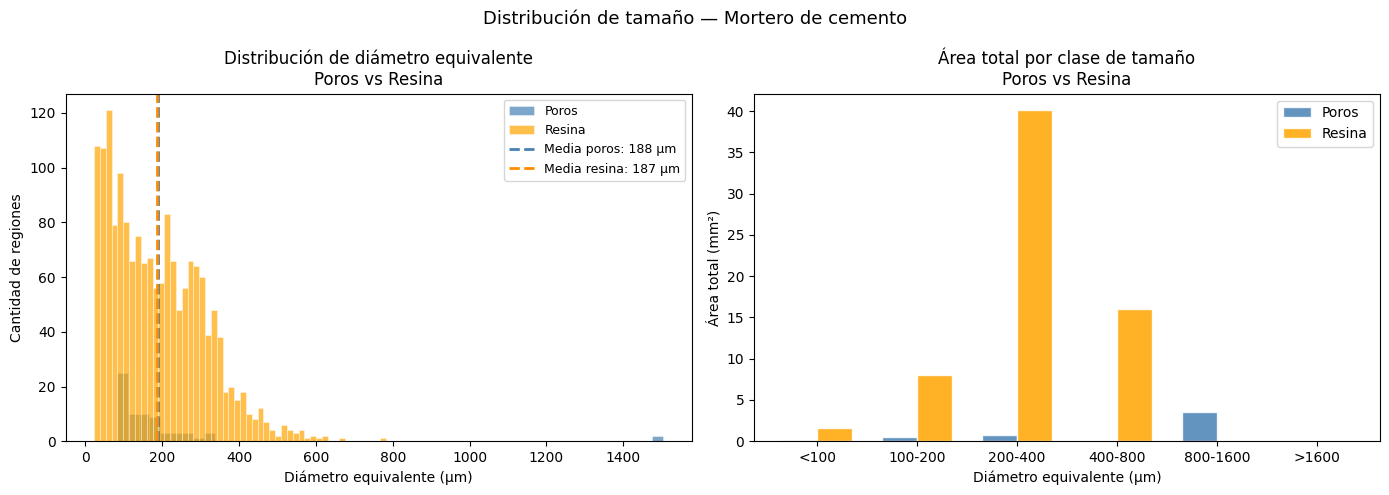

  Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis\figures\05_distribucion_tamano_fases.png


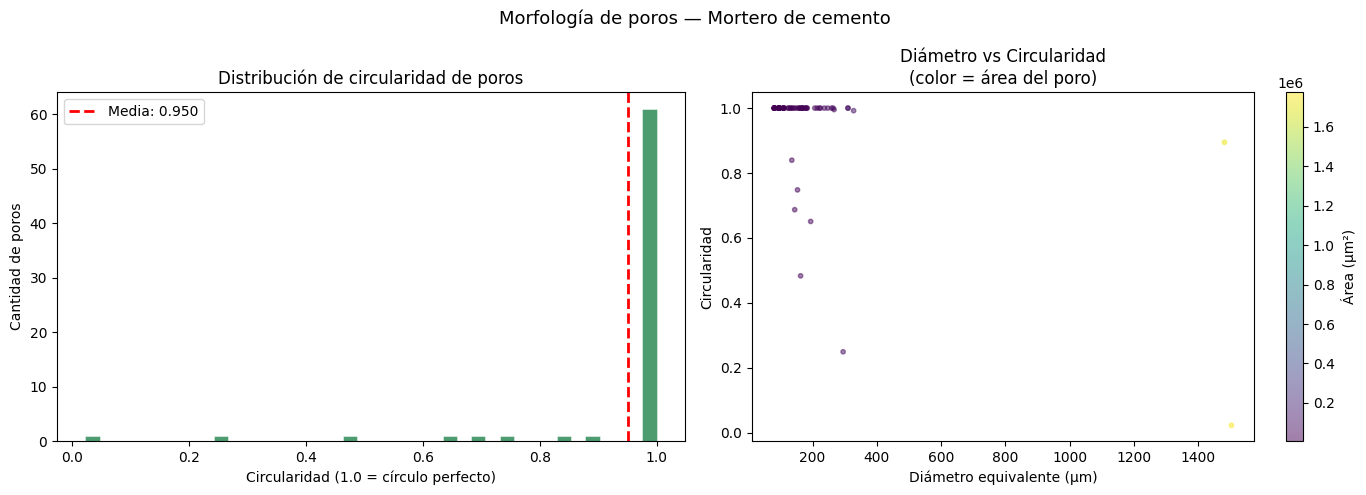

  Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis\figures\05_circularidad_poros.png


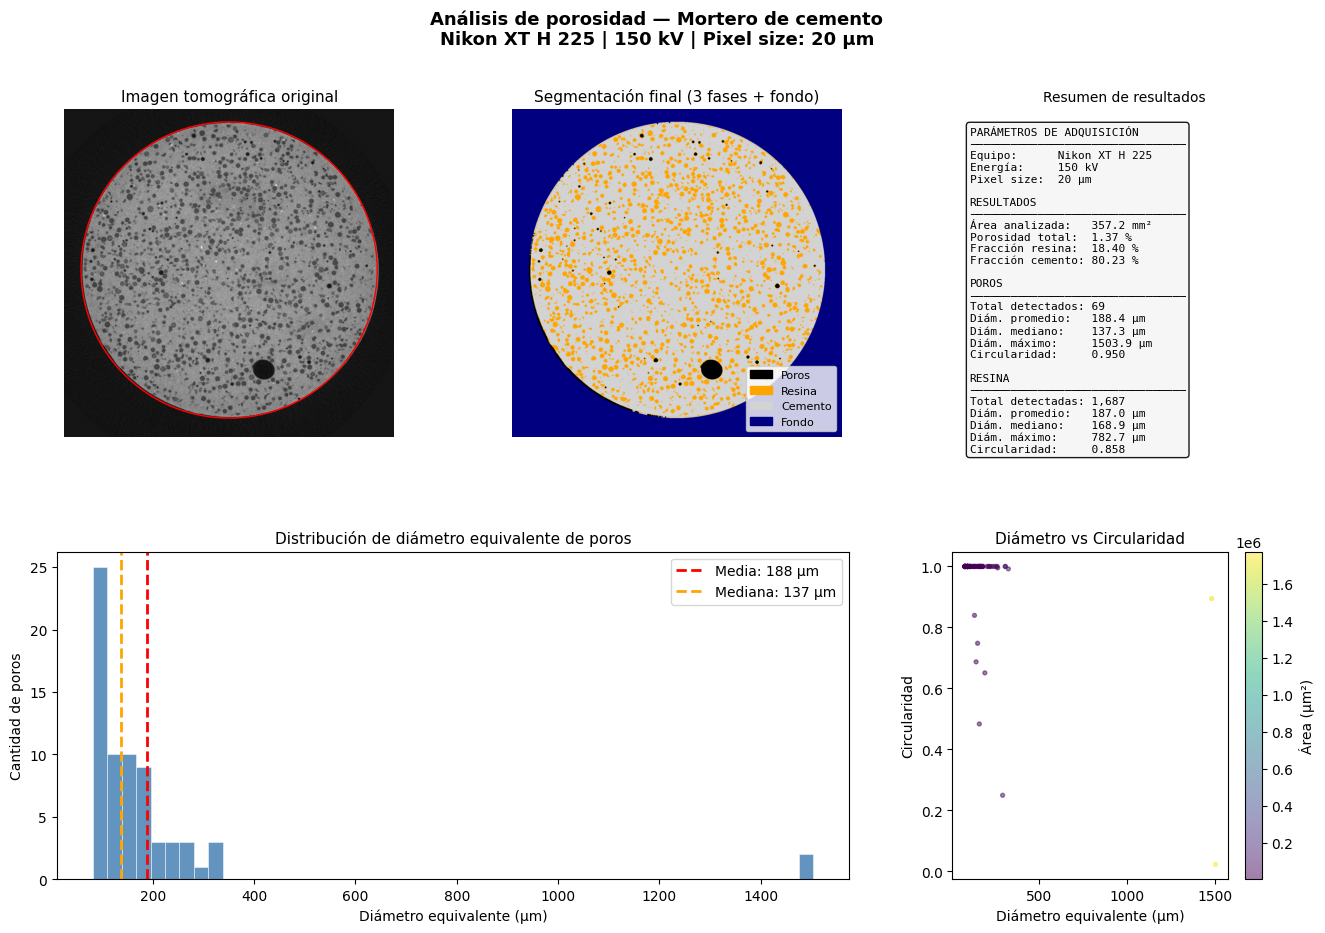

  Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis\figures\05_resumen_final.png
  Reporte JSON guardado en: C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis\results\summary_report.json

  Contenido:
{
    "acquisition": {
        "equipment": "Nikon XT H 225",
        "energy_kV": 150,
        "pixel_size_um": 20,
        "material": "Mortero de cemento",
        "phases": [
            "Poros",
            "Resina",
            "Matriz de cemento"
        ]
    },
    "porosity": {
        "total_pct": 1.3717,
        "resin_pct": 18.4004,
        "cement_pct": 80.2279,
        "area_roi_mm2": 357.2432
    },
    "pore_statistics": {
        "n_pores": 69,
        "diameter_mean_um": 188.4,
        "diameter_median_um": 137.27,
        "diameter_std_um": 236.09,
        "diameter_max_um": 1503.92,
        "circularity_mean": 0.9502,
        "circularity_std": 0.1687
    },
    "resin_statistics": {
        "n_regions"

In [26]:
# ============================================================
# 5 - Resultados cuantitativos y visualización final
# ============================================================
# Objetivo: convertir la segmentación en ciencia comunicable.
#   1. Porosidad total en unidades físicas reales
#   2. Distribución de tamaño de poros
#   3. Distribución de circularidad
#   4. Figura final publicable con todos los resultados
#   5. Reporte resumen exportable
#
# Este acto es el que convierte el notebook en un resultado
# científico — no solo en código que corre.
# ============================================================

# ------------------------------------------------------------
# 5.1 - Cálculo de porosidad total corregida
# Denominador = píxeles dentro de la ROI (no total imagen)
# Eso excluye el fondo exterior y da un valor físicamente real
# ------------------------------------------------------------

def compute_porosity(mask_clean: np.ndarray,
                     roi_mask: np.ndarray,
                     pixel_size_um: float) -> dict:
    """
    Calcula porosidad total y fracción de cada fase
    usando como denominador el área de la ROI.

    Parameters
    ----------
    mask_clean    : np.ndarray  Máscara limpia con ROI aplicada
    roi_mask      : np.ndarray  Máscara booleana de la ROI
    pixel_size_um : float       Tamaño de pixel en µm

    Returns
    -------
    dict con métricas de porosidad y fracciones de fase
    """
    px2_um2   = pixel_size_um ** 2          # µm² por pixel
    area_roi  = roi_mask.sum()              # píxeles totales en ROI
    area_roi_um2 = area_roi * px2_um2       # área ROI en µm²
    area_roi_mm2 = area_roi_um2 / 1e6       # área ROI en mm²

    # Contar píxeles por fase dentro de la ROI
    n_pores   = np.sum((mask_clean == 0) & roi_mask)
    n_resin   = np.sum((mask_clean == 1) & roi_mask)
    n_cement  = np.sum((mask_clean == 2) & roi_mask)

    porosity  = (n_pores  / area_roi) * 100
    f_resin   = (n_resin  / area_roi) * 100
    f_cement  = (n_cement / area_roi) * 100

    return {
        "area_roi_mm2"   : area_roi_mm2,
        "porosity_pct"   : porosity,
        "resin_pct"      : f_resin,
        "cement_pct"     : f_cement,
        "n_pores_total"  : int(np.sum(mask_clean == 0)),
        "n_pore_objects" : len(df_pores),
    }

results = compute_porosity(mask_clean, roi_mask, pixel_size)

print("=" * 50)
print("Resultados de porosidad")
print("=" * 50)
print(f"  Área ROI analizada   : {results['area_roi_mm2']:.2f} mm²")
print(f"  Porosidad total      : {results['porosity_pct']:.2f} %")
print(f"  Fracción resina      : {results['resin_pct']:.2f} %")
print(f"  Fracción cemento     : {results['cement_pct']:.2f} %")
print(f"  Poros individuales   : {results['n_pore_objects']}")
print(f"\n  Check: {results['porosity_pct']:.1f} + "
      f"{results['resin_pct']:.1f} + "
      f"{results['cement_pct']:.1f} = "
      f"{results['porosity_pct'] + results['resin_pct'] + results['cement_pct']:.1f} %"
      f"  {'✓' if abs(results['porosity_pct'] + results['resin_pct'] + results['cement_pct'] - 100) < 1 else '⚠ Revisar'}")

# ------------------------------------------------------------
# 5.2 - Distribución de tamaño de poros
# ------------------------------------------------------------
def plot_pore_size_distribution(df_pores: pd.DataFrame,
                                 df_resin: pd.DataFrame,
                                 save_path: Path) -> None:
    """
    Histograma comparativo de distribución de diámetros
    para poros y regiones de resina.

    Parameters
    ----------
    df_pores  : pd.DataFrame  DataFrame de poros
    df_resin  : pd.DataFrame  DataFrame de resina
    save_path : Path          Ruta donde guardar la figura
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Histograma comparativo poros vs resina ---
    axes[0].hist(df_pores["diameter_um"], bins=50,
                 color="steelblue", alpha=0.7,
                 edgecolor="white", linewidth=0.4,
                 label="Poros")
    axes[0].hist(df_resin["diameter_um"], bins=50,
                 color="orange", alpha=0.7,
                 edgecolor="white", linewidth=0.4,
                 label="Resina")
    axes[0].axvline(df_pores["diameter_um"].mean(), color="steelblue",
                    linewidth=2, linestyle="--",
                    label=f"Media poros: {df_pores['diameter_um'].mean():.0f} µm")
    axes[0].axvline(df_resin["diameter_um"].mean(), color="darkorange",
                    linewidth=2, linestyle="--",
                    label=f"Media resina: {df_resin['diameter_um'].mean():.0f} µm")
    axes[0].set_title("Distribución de diámetro equivalente\nPoros vs Resina",
                      fontsize=12)
    axes[0].set_xlabel("Diámetro equivalente (µm)")
    axes[0].set_ylabel("Cantidad de regiones")
    axes[0].legend(fontsize=9)

    # --- Área acumulada por rango de tamaño — ambas fases ---
    max_diameter = max(df_pores["diameter_um"].max(),
                   df_resin["diameter_um"].max())
    max_bin      = max(max_diameter + 1, 1601)
    
    bins     = [0, 100, 200, 400, 800, 1600, max_bin]
    labels_b = ["<100", "100-200", "200-400",
                "400-800", "800-1600", ">1600"]
    
    df_pores["size_class"] = pd.cut(df_pores["diameter_um"],
                                     bins=bins, labels=labels_b)
    df_resin["size_class"] = pd.cut(df_resin["diameter_um"],
                                     bins=bins, labels=labels_b)

    area_pores = df_pores.groupby("size_class", observed=True)["area_um2"].sum() / 1e6
    area_resin = df_resin.groupby("size_class", observed=True)["area_um2"].sum() / 1e6
    
    # Garantizar que ambas series tengan todas las categorías
    area_pores = area_pores.reindex(labels_b, fill_value=0)
    area_resin = area_resin.reindex(labels_b, fill_value=0)

    x       = range(len(labels_b))
    width   = 0.35
    axes[1].bar([i - width/2 for i in x], area_pores.values,
                width=width, color="steelblue", alpha=0.85,
                edgecolor="white", label="Poros")
    axes[1].bar([i + width/2 for i in x], area_resin.values,
                width=width, color="orange", alpha=0.85,
                edgecolor="white", label="Resina")
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(labels_b)
    axes[1].set_title("Área total por clase de tamaño\nPoros vs Resina",
                      fontsize=12)
    axes[1].set_xlabel("Diámetro equivalente (µm)")
    axes[1].set_ylabel("Área total (mm²)")
    axes[1].legend(fontsize=10)

    plt.suptitle("Distribución de tamaño — Mortero de cemento", fontsize=13)
    plt.tight_layout()
    out = save_path / "05_distribucion_tamano_fases.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Figura guardada en: {out}")

plot_pore_size_distribution(df_pores, df_resin, FIGURES_DIR)

# ------------------------------------------------------------
# 5.3 - Distribución de circularidad
# ------------------------------------------------------------

def plot_circularity_distribution(df: pd.DataFrame,
                                   save_path: Path) -> None:
    """
    Histograma de circularidad de poros.
    Circularidad = 1.0 para un círculo perfecto.
    Valores bajos indican poros elongados o irregulares.

    Parameters
    ----------
    df        : pd.DataFrame  DataFrame de poros del Acto 4
    save_path : Path          Ruta donde guardar la figura
    """
    # Filtrar valores fuera de rango físico
    df_circ = df[df["circularity"] <= 1.05].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma de circularidad
    axes[0].hist(df_circ["circularity"], bins=40,
                 color="seagreen", alpha=0.85,
                 edgecolor="white", linewidth=0.4)
    axes[0].axvline(df_circ["circularity"].mean(), color="red",
                    linewidth=2, linestyle="--",
                    label=f"Media: {df_circ['circularity'].mean():.3f}")
    axes[0].set_title("Distribución de circularidad de poros", fontsize=12)
    axes[0].set_xlabel("Circularidad (1.0 = círculo perfecto)")
    axes[0].set_ylabel("Cantidad de poros")
    axes[0].legend(fontsize=10)

    # Scatter: diámetro vs circularidad
    sc = axes[1].scatter(df_circ["diameter_um"],
                         df_circ["circularity"],
                         c=df_circ["area_um2"],
                         cmap="viridis", alpha=0.5, s=10)
    plt.colorbar(sc, ax=axes[1], label="Área (µm²)")
    axes[1].set_title("Diámetro vs Circularidad\n(color = área del poro)",
                      fontsize=12)
    axes[1].set_xlabel("Diámetro equivalente (µm)")
    axes[1].set_ylabel("Circularidad")

    plt.suptitle("Morfología de poros — Mortero de cemento", fontsize=13)
    plt.tight_layout()
    out = save_path / "05_circularidad_poros.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Figura guardada en: {out}")

plot_circularity_distribution(df_pores, FIGURES_DIR)

# ------------------------------------------------------------
# 5.4 - Figura final publicable
# Resumen visual completo del análisis en una sola figura.
# Esta es la figura que va al README del proyecto.
# ------------------------------------------------------------

def plot_final_summary(img: np.ndarray,
                       mask_clean: np.ndarray,
                       roi_mask: np.ndarray,
                       df_pores: pd.DataFrame,
                       df_resin: pd.DataFrame,
                       results: dict,
                       params: dict,
                       save_path: Path) -> None:
    """
    Figura resumen publicable con imagen original,
    segmentación final y métricas principales.

    Parameters
    ----------
    img        : np.ndarray  Imagen preprocesada
    mask_clean : np.ndarray  Máscara final limpia
    roi_mask   : np.ndarray  Máscara ROI
    df         : pd.DataFrame DataFrame de poros
    results    : dict        Métricas de porosidad
    params     : dict        Parámetros de adquisición
    save_path  : Path        Ruta donde guardar la figura
    """
    import matplotlib.patches as mpatches
    import matplotlib.gridspec as gridspec

    colors     = ["black", "orange", "lightgray", "navy"]
    labels_txt = ["Poros", "Resina", "Cemento", "Fondo"]
    cmap4      = mcolors.ListedColormap(colors)

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig,
                            hspace=0.35, wspace=0.3)

    # --- Imagen original ---
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(img, cmap="gray")
    ax0.contour(roi_mask, levels=[0.5], colors="red", linewidths=1)
    ax0.set_title("Imagen tomográfica original", fontsize=11)
    ax0.axis("off")

    # --- Segmentación final ---
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.imshow(mask_clean, cmap=cmap4, vmin=0, vmax=3)
    ax1.set_title("Segmentación final (3 fases + fondo)", fontsize=11)
    ax1.axis("off")
    patches = [mpatches.Patch(color=c, label=l)
               for c, l in zip(colors, labels_txt)]
    ax1.legend(handles=patches, loc="lower right",
               fontsize=8, framealpha=0.8)

    # --- Métricas textuales ---
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.axis("off")
    metrics_text = (
        f"PARÁMETROS DE ADQUISICIÓN\n"
        f"{'─'*32}\n"
        f"Equipo:      {params['equipment']}\n"
        f"Energía:     {params['energy_kV']} kV\n"
        f"Pixel size:  {params['pixel_size_um']} µm\n\n"
        f"RESULTADOS\n"
        f"{'─'*32}\n"
        f"Área analizada:   {results['area_roi_mm2']:.1f} mm²\n"
        f"Porosidad total:  {results['porosity_pct']:.2f} %\n"
        f"Fracción resina:  {results['resin_pct']:.2f} %\n"
        f"Fracción cemento: {results['cement_pct']:.2f} %\n\n"
        f"POROS\n"
        f"{'─'*32}\n"
        f"Total detectados: {results['n_pore_objects']:,}\n"
        f"Diám. promedio:   {df_pores['diameter_um'].mean():.1f} µm\n"
        f"Diám. mediano:    {df_pores['diameter_um'].median():.1f} µm\n"
        f"Diám. máximo:     {df_pores['diameter_um'].max():.1f} µm\n"
        f"Circularidad:     {df_pores['circularity'].mean():.3f}\n\n"
        f"RESINA\n"
        f"{'─'*32}\n"
        f"Total detectadas: {len(df_resin):,}\n"
        f"Diám. promedio:   {df_resin['diameter_um'].mean():.1f} µm\n"
        f"Diám. mediano:    {df_resin['diameter_um'].median():.1f} µm\n"
        f"Diám. máximo:     {df_resin['diameter_um'].max():.1f} µm\n"
        f"Circularidad:     {df_resin['circularity'].mean():.3f}"
    )
    ax2.text(0.05, 0.95, metrics_text,
             transform=ax2.transAxes,
             fontsize=8, verticalalignment="top",
             fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="whitesmoke",
                       alpha=0.9))
    ax2.set_title("Resumen de resultados", fontsize=10)

    # --- Distribución de diámetros ---
    ax3 = fig.add_subplot(gs[1, 0:2])
    ax3.hist(df_pores["diameter_um"], bins=50, color="steelblue",
             alpha=0.85, edgecolor="white", linewidth=0.4)
    ax3.axvline(df_pores["diameter_um"].mean(),   color="red",
                linewidth=2, linestyle="--",
                label=f"Media: {df_pores['diameter_um'].mean():.0f} µm")
    ax3.axvline(df_pores["diameter_um"].median(), color="orange",
                linewidth=2, linestyle="--",
                label=f"Mediana: {df_pores['diameter_um'].median():.0f} µm")
    ax3.set_title("Distribución de diámetro equivalente de poros",
                  fontsize=11)
    ax3.set_xlabel("Diámetro equivalente (µm)")
    ax3.set_ylabel("Cantidad de poros")
    ax3.legend(fontsize=10)

    # --- Scatter diámetro vs circularidad ---
    ax4 = fig.add_subplot(gs[1, 2])
    df_circ = df_pores[df_pores["circularity"] <= 1.05]
    sc = ax4.scatter(df_circ["diameter_um"],
                     df_circ["circularity"],
                     c=df_circ["area_um2"],
                     cmap="viridis", alpha=0.5, s=8)
    plt.colorbar(sc, ax=ax4, label="Área (µm²)")
    ax4.set_title("Diámetro vs Circularidad", fontsize=11)
    ax4.set_xlabel("Diámetro equivalente (µm)")
    ax4.set_ylabel("Circularidad")

    plt.suptitle(
        f"Análisis de porosidad — Mortero de cemento\n"
        f"{params['equipment']} | {params['energy_kV']} kV | "
        f"Pixel size: {params['pixel_size_um']} µm",
        fontsize=13, fontweight="bold"
    )

    out = save_path / "05_resumen_final.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Figura guardada en: {out}")

plot_final_summary(img_preprocessed, mask_clean, roi_mask,
                   df_pores, df_resin, results,
                   ACQUISITION_PARAMS, FIGURES_DIR)

# ------------------------------------------------------------
# 5.5 - Reporte resumen exportable
# ------------------------------------------------------------

def export_summary_report(results: dict, df_pores: pd.DataFrame,
                           df_resin: pd.DataFrame,
                           params: dict, save_path: Path) -> None:
    """
    Exporta un reporte resumen en formato JSON con todos
    los parámetros y resultados del análisis.
    Pensado para ser leído por el pipeline 3D del Proyecto 2.

    Parameters
    ----------
    results   : dict         Métricas de porosidad
    df        : pd.DataFrame DataFrame de poros
    params    : dict         Parámetros de adquisición
    save_path : Path         Ruta donde guardar el reporte
    """
    import json

    report = {
        "acquisition": params,
        "porosity": {
            "total_pct"       : round(results["porosity_pct"], 4),
            "resin_pct"       : round(results["resin_pct"], 4),
            "cement_pct"      : round(results["cement_pct"], 4),
            "area_roi_mm2"    : round(results["area_roi_mm2"], 4),
        },
        "pore_statistics": {
            "n_pores"              : results["n_pore_objects"],
            "diameter_mean_um"     : round(df_pores["diameter_um"].mean(), 2),
            "diameter_median_um"   : round(df_pores["diameter_um"].median(), 2),
            "diameter_std_um"      : round(df_pores["diameter_um"].std(), 2),
            "diameter_max_um"      : round(df_pores["diameter_um"].max(), 2),
            "circularity_mean"     : round(df_pores["circularity"].mean(), 4),
            "circularity_std"      : round(df_pores["circularity"].std(), 4),
        },
        "resin_statistics": {
            "n_regions"            : len(df_resin),
            "diameter_mean_um"     : round(df_resin["diameter_um"].mean(), 2),
            "diameter_median_um"   : round(df_resin["diameter_um"].median(), 2),
            "diameter_std_um"      : round(df_resin["diameter_um"].std(), 2),
            "diameter_max_um"      : round(df_resin["diameter_um"].max(), 2),
            "circularity_mean"     : round(df_resin["circularity"].mean(), 4),
            "circularity_std"      : round(df_resin["circularity"].std(), 4),
        },
        "pipeline": {
            "filter_used"      : FILTER_SELECTED,
            "opening_radius"   : OPENING_RADIUS,
            "closing_radius"   : CLOSING_RADIUS,
            "min_pore_size_px" : MIN_PORE_SIZE,
            "roi_threshold"    : ROI_THRESHOLD,
        }
    }

    out = save_path / "summary_report.json"
    with open(out, "w") as f:
        json.dump(report, f, indent=4)
    print(f"  Reporte JSON guardado en: {out}")
    print(f"\n  Contenido:")
    print(json.dumps(report, indent=4))

export_summary_report(results, df_pores, df_resin, ACQUISITION_PARAMS, RESULTS_DIR)
#export_summary_report(results, df_pores, ACQUISITION_PARAMS, RESULTS_DIR)

print("\n")
print("=" * 50)
print("✓ Análisis completo")
print("=" * 50)
print(f"  Figuras generadas en : {FIGURES_DIR}")
print(f"  Resultados en        : {RESULTS_DIR}")
print(f"\n  Próximo paso         : Proyecto 02 — Análisis 3D")
print(f"  del volumen completo usando este pipeline escalado.")